<a href="https://colab.research.google.com/github/eilonyanko/knn-vs-decision-tree-classification/blob/main/knn_vs_decision_tree_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Name: Eilon Yanko
#ID: 318879277

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Used for uploading local dataset files directly into the Colab environment
from google.colab import files
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
#Loading the file with drag and drop, and transforming it to a dataset

data = pd.read_csv('breast_cacncer_data.csv')

In [ ]:
#Displaying the first 5 rows of the dataset

data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
#basic statistics of every numerical feature in the dataset

data.drop(columns='id').describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
#displaying the info of the dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

# NaN Values

There are no NaN values, so no further action is required.

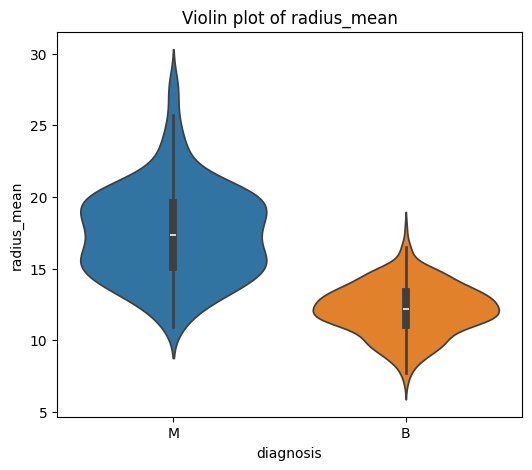

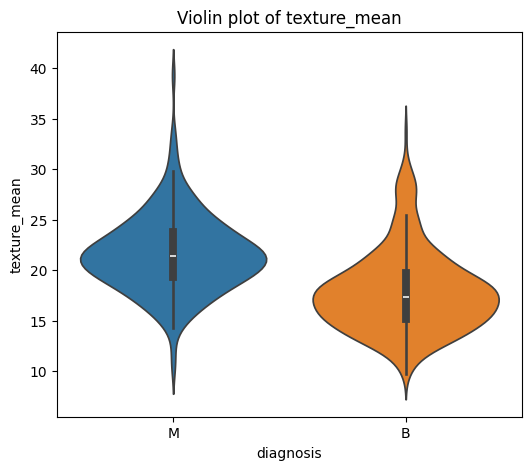

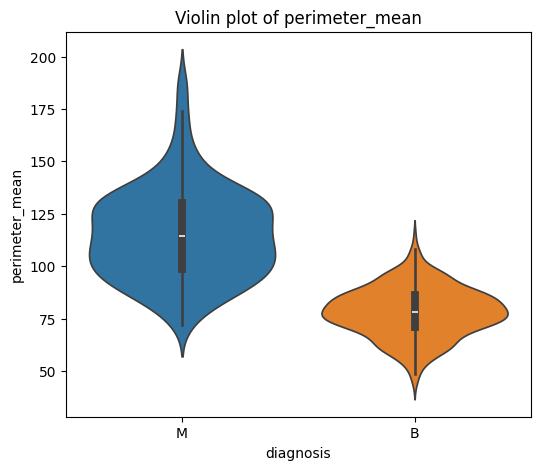

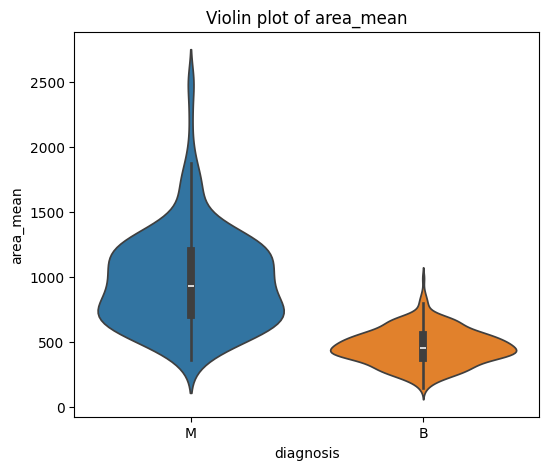

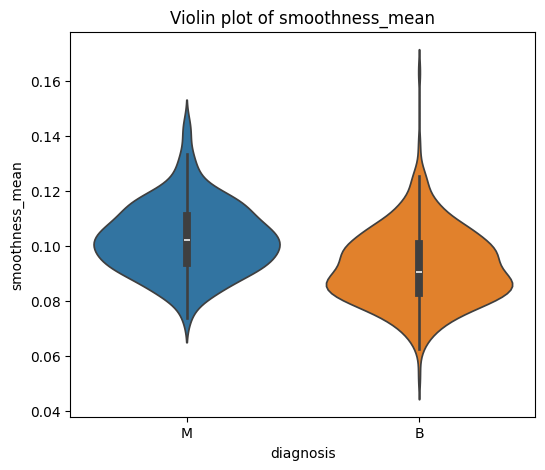

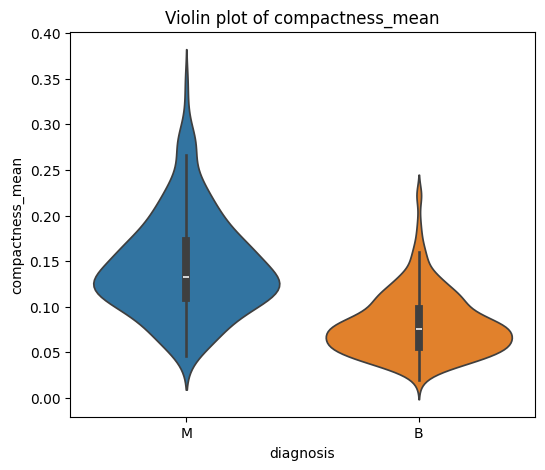

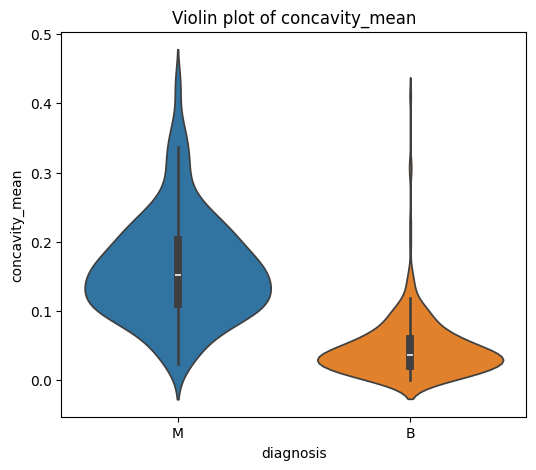

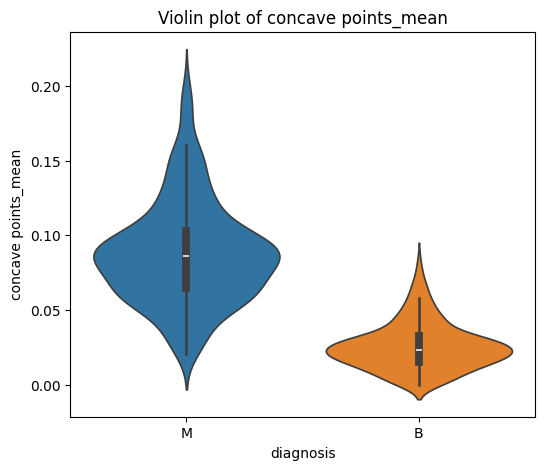

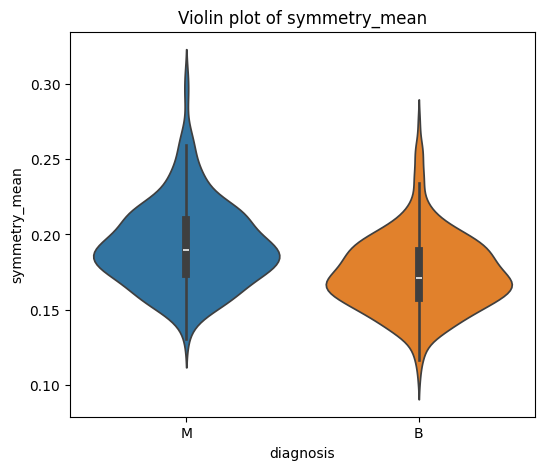

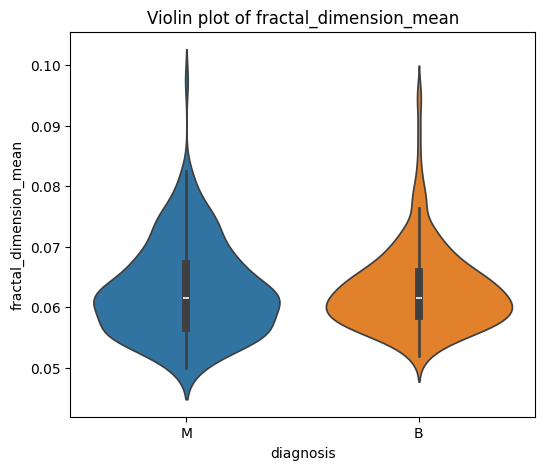

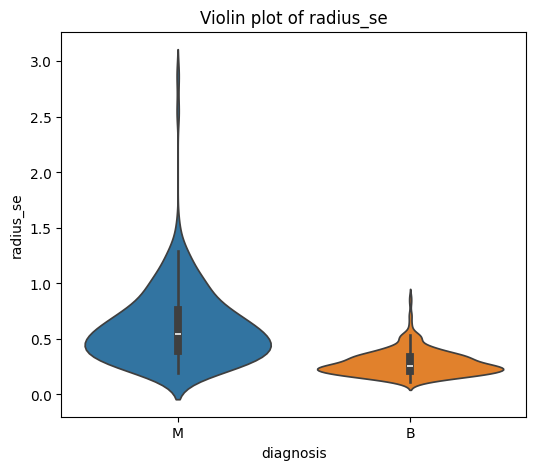

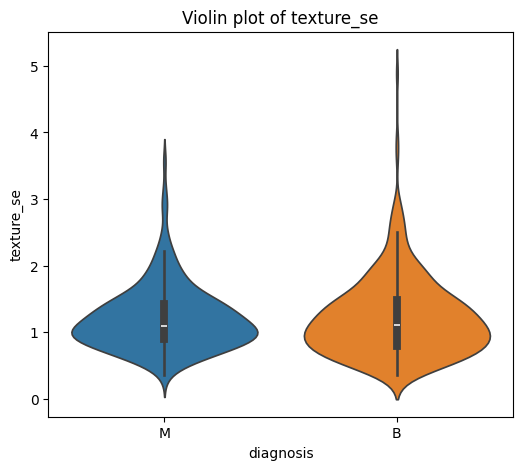

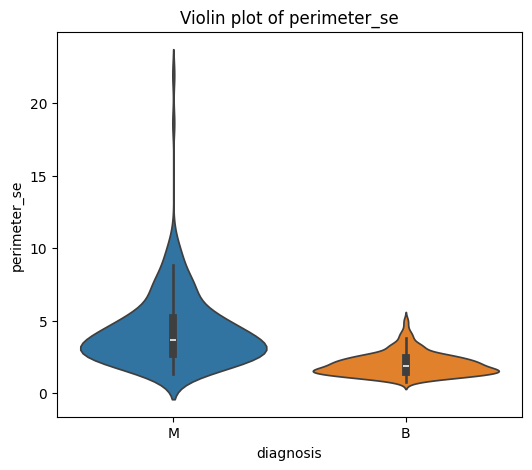

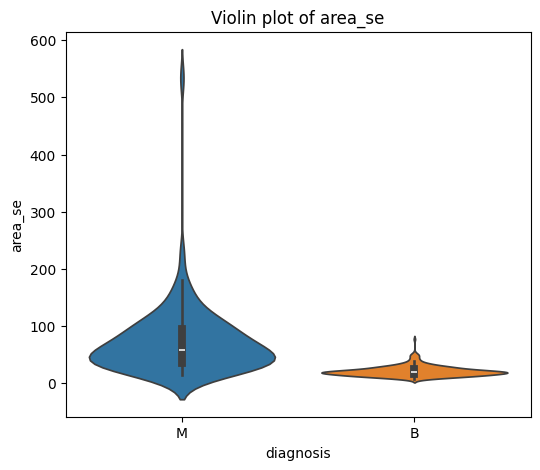

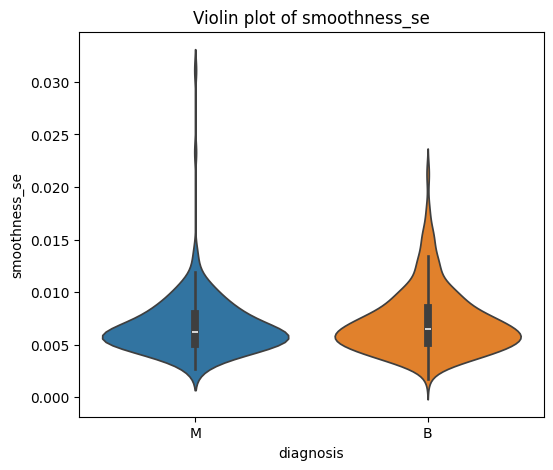

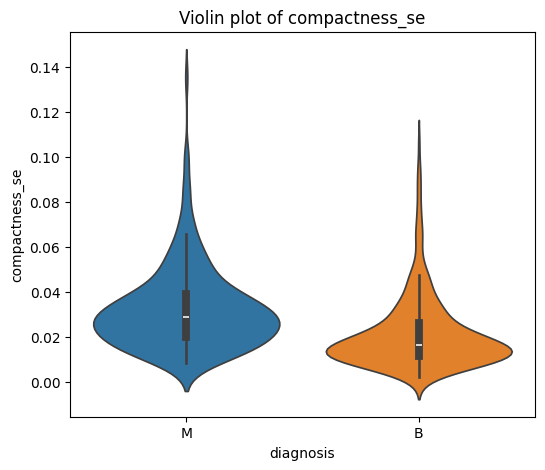

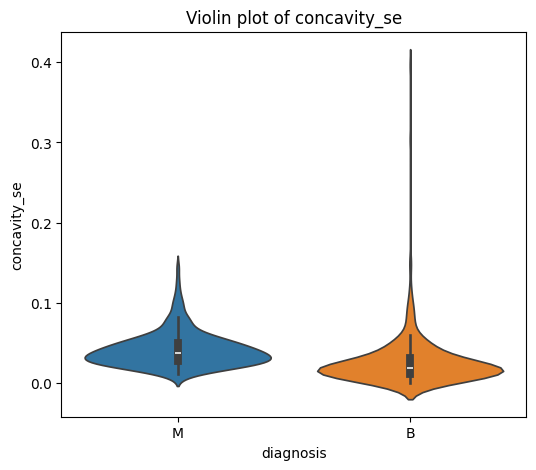

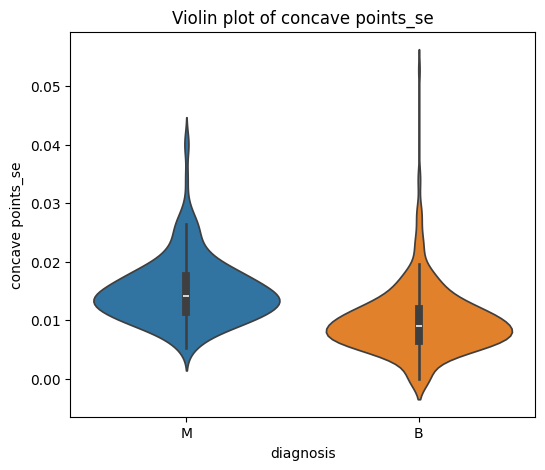

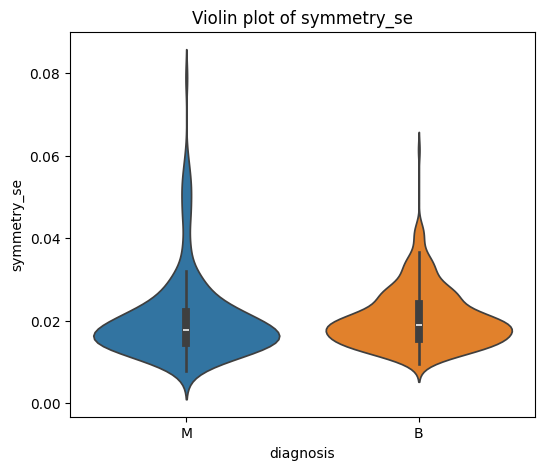

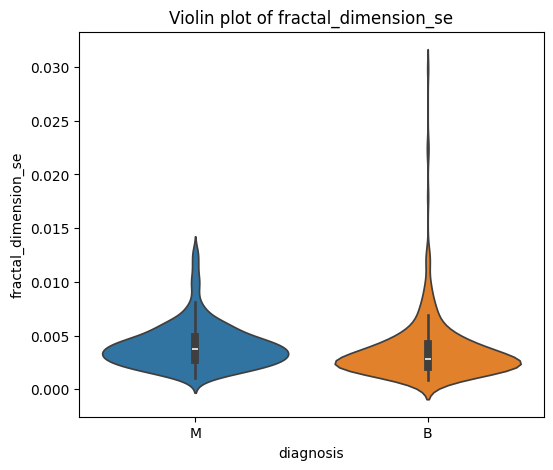

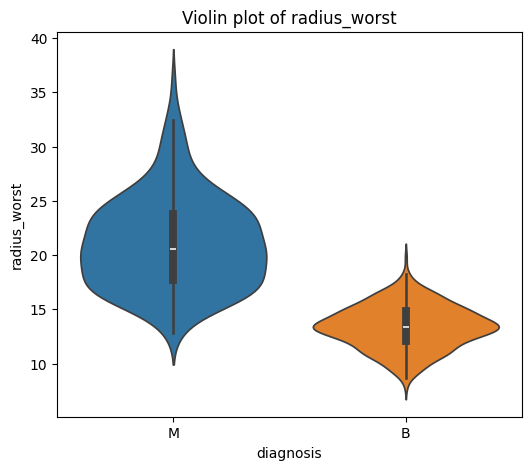

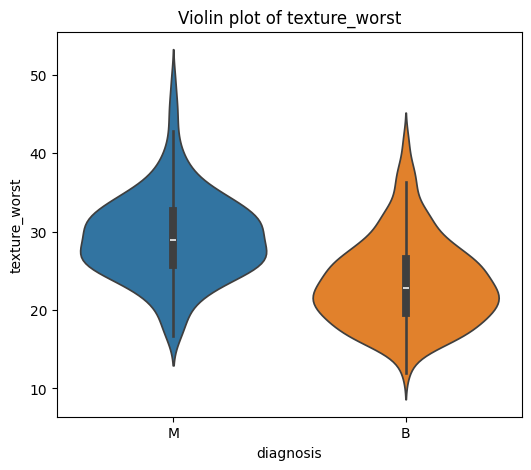

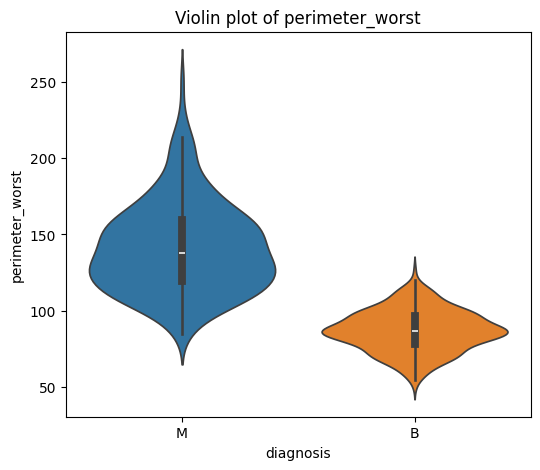

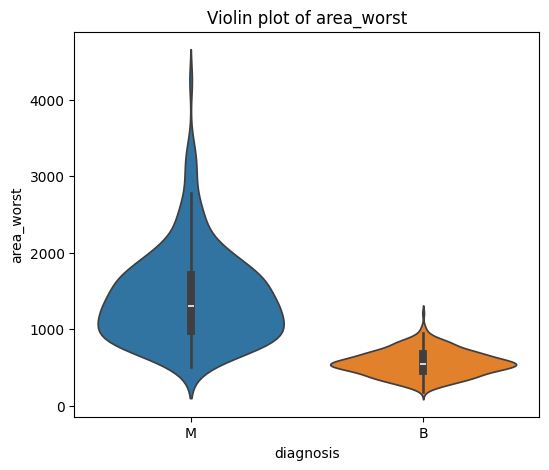

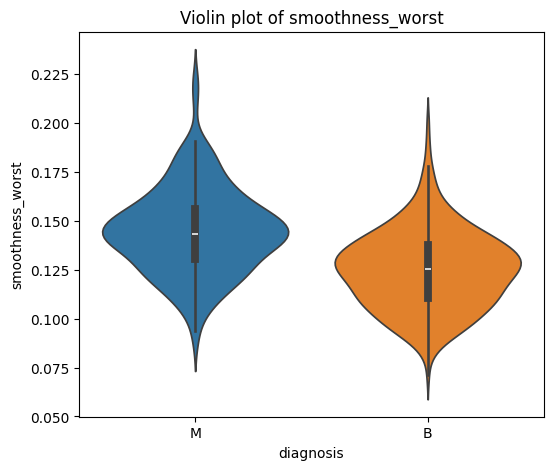

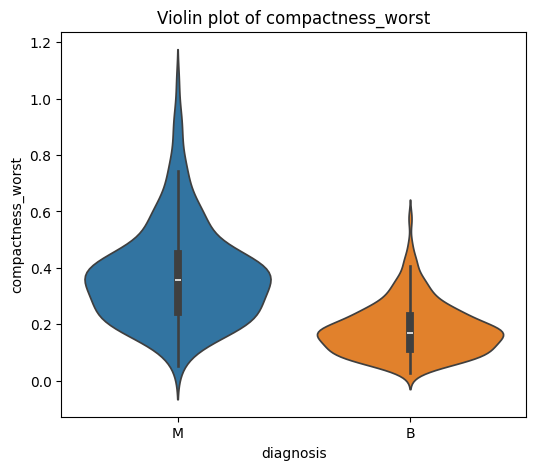

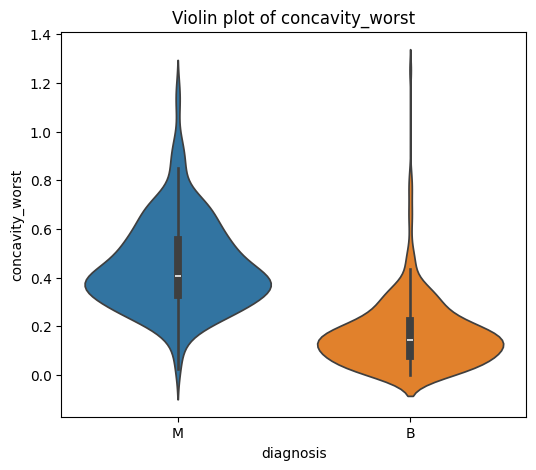

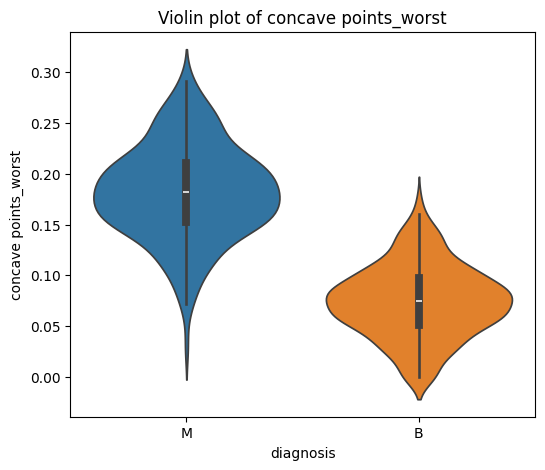

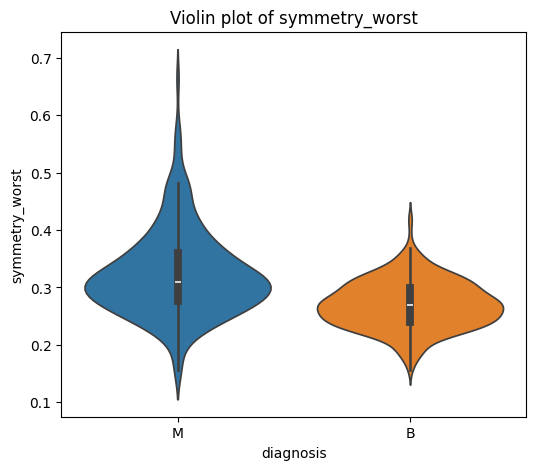

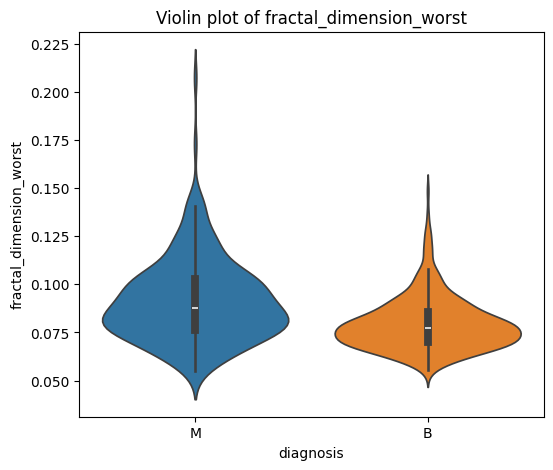

In [ ]:
#creating violin plots for every feature, to find the difference between malignant and benign cancer in that specific feature

numericFeatures = data.select_dtypes(include=['float64']).columns

for feature in numericFeatures:
    plt.figure(figsize=(6,5))
    sns.violinplot(data=data, x='diagnosis', y=feature, hue='diagnosis')
    plt.title(f'Violin plot of {feature}')
    plt.show()

<Axes: >

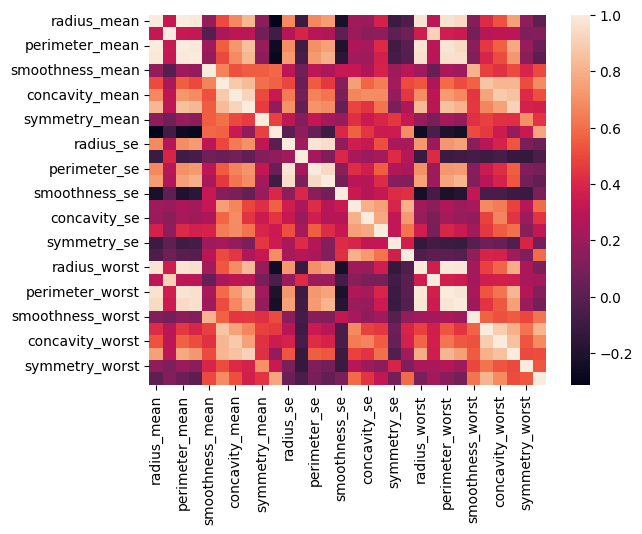

In [ ]:
#Correlation matrix of the entire dataset (it doesn't show its entirety, maybe because the heatmap is limited by matrix size)

corrMat = data.drop(columns=['id', 'diagnosis']).corr()
sns.heatmap(corrMat)

# Visualization Insights

From the violin plots, we can see that the diagnosis is correlated the most with: radius, perimeter, area, compactness, concavity, and concave points.
The mean column is a good representative of each feature, so I decided to drop all the columns of each feature that is se or worst. I'll also discard the ID feature, because it doesn't influence the diagnosis.

<Axes: >

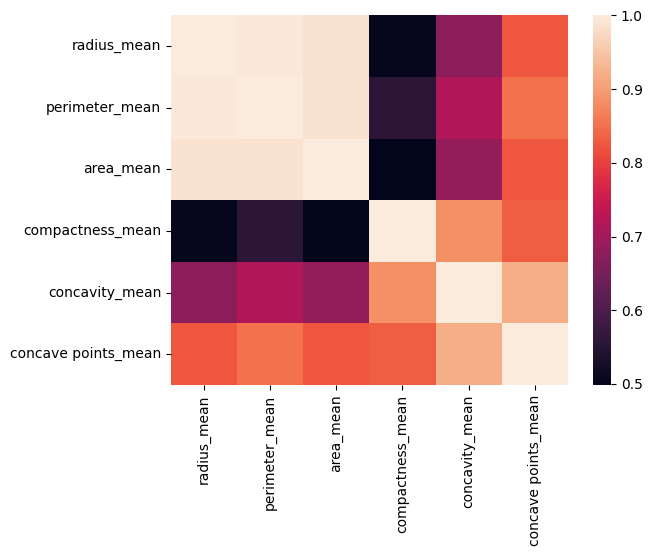

In [ ]:
#Correlation matrix of the columns that interest us

dataMean = data[['diagnosis', 'radius_mean', 'perimeter_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean']]
corrMatMean = dataMean.drop(columns='diagnosis').corr()
sns.heatmap(corrMatMean)

# Correlation Matrix Insights

We can see a trivial correlation between the radius, area, and perimeter features.

In [ ]:
#Normalization and data split

x = dataMean.drop(columns='diagnosis')
y, labels = dataMean['diagnosis'].factorize()

x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=777)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, train_size=0.5, test_size=0.5, random_state=777)

#KNN Model

In [ ]:
#Manual hyperparameter tuning

scoreMax = 0
kOpt = 0
distanceOpt = 0
for k in range(1, 11):
  for d in range(10, 21):
    metricD = d/10
    knn = KNeighborsClassifier(n_neighbors=k, p=metricD)
    knn.fit(x_train, y_train)
    y_valPred = knn.predict(x_val)
    score = knn.score(x_val, y_val)
    if score > scoreMax:
      scoreMax = score
      kOpt = k
      distanceOpt = metricD

print(f'k = {kOpt}, p = {distanceOpt}, score = {scoreMax}')

k = 5, p = 1.9, score = 0.8705882352941177


# Manual Hyperparameter Tuning

By using manual parameter tuning, I got to the optimal parameters printed above.

In [ ]:
#GridSearchCV hyperparameter tuning

from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

paramGrid = {
    'n_neighbors': range(1, 11),
    'p': np.arange(1, 2.1, 0.1)
}

grid = GridSearchCV(
    estimator=knn,
    param_grid=paramGrid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'n_neighbors': 9, 'p': np.float64(1.8000000000000007)}
Best Score: 0.8893037974683544


#GridSearchCV

After using GridSearchCV, I got a better score as printed above.

In [ ]:
#KNN model with the optimal values from GridSearchCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn = KNeighborsClassifier(n_neighbors=9, p=1.8)
knn.fit(x_train, y_train)
y_valPred = knn.predict(x_val)

print("Accuracy :", accuracy_score(y_val, y_valPred))
print("Precision:", precision_score(y_val, y_valPred, average="macro"))
print("Recall   :", recall_score(y_val, y_valPred, average="macro"))
print("F1 Score :", f1_score(y_val, y_valPred, average="macro"))

Accuracy : 0.8470588235294118
Precision: 0.8504464285714286
Recall   : 0.7951127819548872
F1 Score : 0.8136279305110474


In [ ]:
#KNN model with the optimal values from the manual tuning

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn = KNeighborsClassifier(n_neighbors=5, p=1.9)
knn.fit(x_train, y_train)
y_valPred = knn.predict(x_val)

print("Accuracy :", accuracy_score(y_val, y_valPred))
print("Precision:", precision_score(y_val, y_valPred, average="macro"))
print("Recall   :", recall_score(y_val, y_valPred, average="macro"))
print("F1 Score :", f1_score(y_val, y_valPred, average="macro"))

Accuracy : 0.8705882352941177
Precision: 0.8820684523809523
Recall   : 0.8217418546365916
F1 Score : 0.8423005565862709


#Difference Between Manual and GridSearchCV Hyperparameter Tuning

As seen above, when I used manual hyperparameter tuning, I got better results from the KNN model. I assume it's because optimization in manual search was on validation data, while GridSearchCV optimizes on training data.

[[19  9]
 [ 2 55]]


<Axes: >

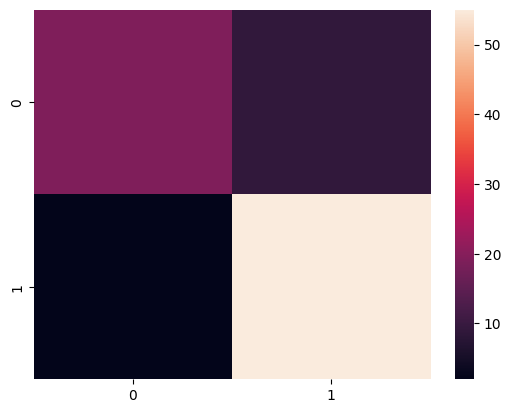

In [ ]:
#Confusion matrix of the KNN model

from sklearn.metrics import confusion_matrix

confMat = confusion_matrix(y_val, y_valPred)
print(confMat)
sns.heatmap(confMat)

#Classification Tree Model

In [ ]:
#Default hyperparameters, except random_state, to obtain a deterministic behaviour during fitting

from sklearn.tree import DecisionTreeClassifier, export_graphviz

decTree = DecisionTreeClassifier(random_state=1)
decTree.fit(x_train, y_train)
score = decTree.score(x_val, y_val)
depth = decTree.get_depth()
leaves = decTree.get_n_leaves()
print(f'The depth for default hyperparameters: {depth}\n')
print(f'The number of leaves for default hyperparameters: {leaves}\n')
print(f'The score for default hyperparameters: {score}')

The depth for default hyperparameters: 9

The number of leaves for default hyperparameters: 28

The score for default hyperparameters: 0.9176470588235294


In [ ]:
#Manual hyperparameter tuning

scoreMax = 0
depthOpt = 0
leavesOpt = 0
for depth in range(2, 11):
  for leaves in range(depth, pow(2, depth-1)+1):
    decTree = DecisionTreeClassifier(max_depth=depth, max_leaf_nodes=leaves, random_state=1)
    decTree.fit(x_train, y_train)
    score = decTree.score(x_val, y_val)
    if score > scoreMax:
      scoreMax = score
      depthOpt = depth
      leavesOpt = leaves

print(f'depth = {depthOpt}, number of leaves = {leavesOpt}, score = {scoreMax}')

depth = 2, number of leaves = 2, score = 0.9529411764705882


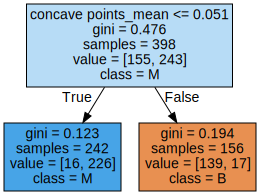

In [ ]:
#A diagram of the tree that was created from the optimal hyperparameters

from IPython.display import SVG
from graphviz import Source

decTree = DecisionTreeClassifier(max_depth=2, max_leaf_nodes=2, random_state=1)
decTree.fit(x_train, y_train)

def plot_tree(tree, features, labels):
    graph = Source(export_graphviz(tree, feature_names=features, class_names=labels, filled = True))
    display(SVG(graph.pipe(format='svg')))

plot_tree(decTree, x.columns.values,  np.unique(data['diagnosis']))

In [ ]:
#Decision Tree model with the optimal values from the manual hyperparameters tuning

y_valPred = decTree.predict(x_val)

print("Accuracy :", accuracy_score(y_val, y_valPred))
print("Precision:", precision_score(y_val, y_valPred, average="macro"))
print("Recall   :", recall_score(y_val, y_valPred, average="macro"))
print("F1 Score :", f1_score(y_val, y_valPred, average="macro"))

Accuracy : 0.872093023255814
Precision: 0.8535067873303167
Recall   : 0.8781004234724743
F1 Score : 0.8622396971020825


[[26  3]
 [ 8 49]]


<Axes: >

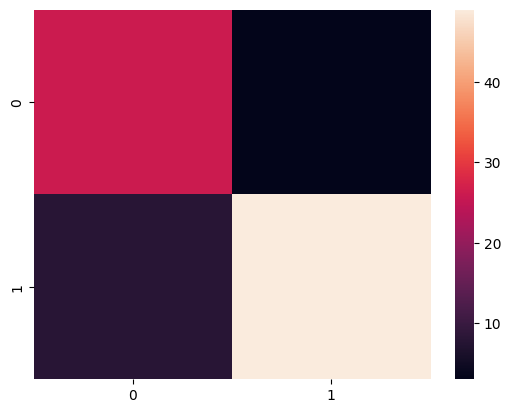

In [ ]:
#Confusion matrix of the Decision Tree model

confMat = confusion_matrix(y_val, y_valPred)
print(confMat)
sns.heatmap(confMat)

#Summary of Findings

KNN model optimal hyperparameters:
k = 5, p = 1.9
score: 0.8705882352941177

Decision Tree model optimal hyperparameters:
depth = 2, number of leaves = 2
score: 0.9529411764705882

In conclusion, I can infer from the score of both models with their own optimal hyperparameters, that the Decision Tree model is the best model for those particular problem and dataset.